# DetectiveQA baseline 2: Dense, Hybrid và Hybrid + Re-ranking

In [1]:
#@title 1. Setting

REPO_URL = "https://github.com/TranTheHung2312332/canon-layer.git" #@param {type:"string"}
BRANCH = "main" #@param {type:"string"}
REPO_DIR = "/content/repo" #@param {type:"string"}

MAX_QUERIES = 0 #@param {type:"integer"}  # 0 = toàn bộ
TOP_K = 10
RUN_DEPTH = 100
RANDOM_SEED = 42

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L6-v2"
QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

RRF_K = 60
RERANK_TOP_N = 50
EMBED_BATCH_SIZE = 128
RERANK_BATCH_SIZE = 64
REBUILD_CACHE = False

In [2]:
#@title 2. Install dependencies

!pip install -q -U faiss-cpu rank-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 67.2 MB/s eta 0:00:00


In [3]:
!pip uninstall -y torchvision
!pip install -U --no-cache-dir sentence-transformers transformers

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 89.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.5.1
    Uninstalling sentence-transformers-5.5.1:
      Successfully uninstalled sentence-transformers-5.5.1


In [4]:
#@title 3. Clone repo

from pathlib import Path
import os, subprocess, torch

if "<YOUR_USERNAME>" in REPO_URL:
    raise ValueError("Hãy thay REPO_URL bằng URL GitHub thật.")

repo_dir = Path(REPO_DIR)
if (repo_dir / ".git").exists():
    subprocess.run(["git","-C",str(repo_dir),"fetch","origin",BRANCH], check=True)
    subprocess.run(["git","-C",str(repo_dir),"checkout",BRANCH], check=True)
    subprocess.run(["git","-C",str(repo_dir),"pull","--ff-only","origin",BRANCH], check=True)
else:
    subprocess.run(
        ["git","clone","--depth","1","--branch",BRANCH,REPO_URL,str(repo_dir)],
        check=True,
    )

os.chdir(repo_dir)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Working directory:", Path.cwd())
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Khuyến nghị bật T4 GPU trong Colab.")

Working directory: /content/repo
Device: cuda
GPU: Tesla T4


## 4. Load

In [5]:
import json, re
from collections import defaultdict
import numpy as np
import pandas as pd

DATA_DIR = Path("data/detectiveqa-ranking-en")
CORPUS_PATH = DATA_DIR / "corpus.jsonl"
QUERIES_PATH = DATA_DIR / "queries.jsonl"
META_PATH = DATA_DIR / "query_metadata.jsonl"
QRELS_PATH = DATA_DIR / "qrels" / "test.tsv"

for p in [CORPUS_PATH, QUERIES_PATH, META_PATH, QRELS_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

def read_jsonl(path):
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

corpus_records = read_jsonl(CORPUS_PATH)
query_records = read_jsonl(QUERIES_PATH)
meta_records = read_jsonl(META_PATH)

corpus = {x["_id"]: x for x in corpus_records}
queries = {x["_id"]: x["text"] for x in query_records}
query_meta = {x.get("query_id", x.get("_id")): x for x in meta_records}

qrels_df = pd.read_csv(QRELS_PATH, sep="\t")
need = {"query-id","corpus-id","score"}
if not need.issubset(qrels_df.columns):
    raise ValueError(f"qrels thiếu cột: {need - set(qrels_df.columns)}")

gold = defaultdict(set)
for _, row in qrels_df[qrels_df["score"] > 0].drop_duplicates(
    ["query-id","corpus-id"]
).iterrows():
    gold[str(row["query-id"])].add(str(row["corpus-id"]))

DOC_RE = re.compile(r"^dqa-en-(\d+)-p\d+$")
Q_RE = re.compile(r"^dqa-en-(?:human_anno|AIsup_anno)-(\d+)-q\d+$")

def doc_novel_id(doc_id):
    m = DOC_RE.match(doc_id)
    if not m:
        raise ValueError(f"Bad doc id: {doc_id}")
    return int(m.group(1))

def query_novel_id(qid):
    m = query_meta.get(qid, {})
    if m.get("novel_id") is not None:
        return int(m["novel_id"])
    x = Q_RE.match(qid)
    if not x:
        raise ValueError(f"Bad query id: {qid}")
    return int(x.group(1))

if any(not x.startswith("dqa-en-") for x in corpus):
    raise ValueError("Corpus chứa dữ liệu ngoài English release.")
if any(not x.startswith("dqa-en-") for x in queries):
    raise ValueError("Queries chứa dữ liệu ngoài English release.")

missing_gold = {d for ds in gold.values() for d in ds if d not in corpus}
if missing_gold:
    raise ValueError(f"Gold docs không tồn tại: {list(missing_gold)[:5]}")

eval_qids = sorted(q for q in queries if gold.get(q))
if MAX_QUERIES > 0:
    rng = np.random.default_rng(RANDOM_SEED)
    eval_qids = sorted(
        rng.choice(eval_qids, min(MAX_QUERIES, len(eval_qids)), replace=False).tolist()
    )

docs_by_novel = defaultdict(list)
for doc_id in corpus:
    docs_by_novel[doc_novel_id(doc_id)].append(doc_id)

def paragraph_no(doc_id):
    return int(doc_id.rsplit("-p",1)[1])

for nid in docs_by_novel:
    docs_by_novel[nid].sort(key=paragraph_no)

queries_by_novel = defaultdict(list)
for qid in eval_qids:
    queries_by_novel[query_novel_id(qid)].append(qid)

print("Documents:", len(corpus))
print("Queries evaluated:", len(eval_qids))
print("Novels:", len(queries_by_novel))

Documents: 65641
Queries evaluated: 149
Novels: 23


## 5. Metrics

In [6]:
import math

def precision_at_k(ranked, relevant, k):
    return sum(x in relevant for x in ranked[:k]) / k

def recall_at_k(ranked, relevant, k):
    return sum(x in relevant for x in ranked[:k]) / len(relevant) if relevant else 0.0

def reciprocal_rank(ranked, relevant):
    for i, x in enumerate(ranked, 1):
        if x in relevant:
            return 1.0 / i
    return 0.0

def ndcg_at_k(ranked, relevant, k):
    if not relevant:
        return 0.0
    dcg = sum(
        (1.0 if x in relevant else 0.0) / math.log2(i + 1)
        for i, x in enumerate(ranked[:k], 1)
    )
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, min(k,len(relevant)) + 1))
    return dcg / idcg if idcg else 0.0

def evaluate(ranked, relevant):
    return {
        "precision@10": precision_at_k(ranked,relevant,10),
        "recall@10": recall_at_k(ranked,relevant,10),
        "mrr": reciprocal_rank(ranked,relevant),
        "ndcg@10": ndcg_at_k(ranked,relevant,10),
    }

assert precision_at_k(["a","b"], {"b"}, 2) == 0.5
assert reciprocal_rank(["a","b"], {"b"}) == 0.5
print("Metric sanity checks passed.")

Metric sanity checks passed.


## 6. Models và embedding cache

In [7]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from tqdm.auto import tqdm
import faiss
from rank_bm25 import BM25Okapi

embedder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
reranker = CrossEncoder(RERANKER_MODEL, device=DEVICE)

print("Embedding dim:", embedder.get_sentence_embedding_dimension())
print("Max sequence length:", embedder.max_seq_length)

OUT_DIR = Path("artifacts/retrieval_baselines_v2")
CACHE_DIR = OUT_DIR / "embedding_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cache_path(novel_id):
    return CACHE_DIR / f"bge_small_en_v15_novel_{novel_id}.npz"

def load_or_encode_docs(novel_id, doc_ids, texts):
    path = cache_path(novel_id)
    if path.exists() and not REBUILD_CACHE:
        obj = np.load(path, allow_pickle=False)
        if obj["doc_ids"].astype(str).tolist() == doc_ids:
            return obj["embeddings"].astype(np.float32, copy=False)

    emb = embedder.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32, copy=False)

    np.savez(path, doc_ids=np.asarray(doc_ids), embeddings=emb)
    return emb

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Embedding dim: 384
Max sequence length: 512


/tmp/ipykernel_1874/1555711876.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dim:", embedder.get_sentence_embedding_dimension())


## 7. Retrieval helpers

In [8]:
TOKEN_RE = re.compile(r"(?u)\b\w\w+\b")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

def desc(scores):
    return np.argsort(-np.asarray(scores), kind="mergesort")

def ranks_from_order(order):
    ranks = np.empty(len(order), dtype=np.int32)
    ranks[order] = np.arange(1, len(order)+1)
    return ranks

def rrf_fuse(dense_order, bm25_order, k=60):
    dr = ranks_from_order(dense_order)
    br = ranks_from_order(bm25_order)
    score = 1.0/(k+dr) + 1.0/(k+br)
    return desc(score), score.astype(np.float32)

def rerank(query, hybrid_order, texts):
    n = min(RERANK_TOP_N, len(hybrid_order))
    head = hybrid_order[:n]
    pairs = [(query, texts[int(i)]) for i in head]
    scores = np.asarray(
        reranker.predict(
            pairs,
            batch_size=RERANK_BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
    ).reshape(-1)
    new_head = head[desc(scores)]
    final = np.concatenate([new_head, hybrid_order[n:]])
    score_map = {int(head[i]): float(scores[i]) for i in range(n)}
    return final, score_map

## 8. pipelines

- Dense BGE
- Hybrid BM25+BGE (RRF)
- Hybrid + MiniLM reranker

In [9]:
import time
import torch

metric_rows = []
runs = {"dense":[], "hybrid_rrf":[], "hybrid_rerank":[]}
timings = []

for novel_id in tqdm(sorted(queries_by_novel), desc="Novels"):
    doc_ids = docs_by_novel[novel_id]
    texts = [corpus[d]["text"] for d in doc_ids]
    candidate_set = set(doc_ids)

    doc_emb = load_or_encode_docs(novel_id, doc_ids, texts)
    index = faiss.IndexFlatIP(doc_emb.shape[1])
    index.add(np.ascontiguousarray(doc_emb))

    bm25 = BM25Okapi([tokenize(t) for t in texts])

    qids = queries_by_novel[novel_id]
    raw_q = [queries[q] for q in qids]
    q_emb = embedder.encode(
        [QUERY_PREFIX + q for q in raw_q],
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32, copy=False)

    for qi, qid in enumerate(qids):
        question = queries[qid]
        relevant = gold[qid]
        if relevant - candidate_set:
            raise ValueError(f"{qid}: gold ngoài candidate novel")

        started = time.perf_counter()

        # Dense full ranking
        dense_scores, dense_idx = index.search(
            np.ascontiguousarray(q_emb[qi:qi+1]),
            len(doc_ids),
        )
        dense_order = dense_idx[0]
        dense_ranked = [doc_ids[int(i)] for i in dense_order]
        metric_rows.append({
            "method":"Dense BGE-small","query_id":qid,"novel_id":novel_id,
            "num_candidates":len(doc_ids),"num_relevant":len(relevant),
            **evaluate(dense_ranked,relevant),
        })
        for rank, (i,s) in enumerate(zip(dense_order[:RUN_DEPTH],dense_scores[0][:RUN_DEPTH]),1):
            d = doc_ids[int(i)]
            runs["dense"].append({
                "query_id":qid,"doc_id":d,"rank":rank,"score":float(s),
                "relevant":int(d in relevant),
            })

        # BM25 + RRF
        bm25_scores = np.asarray(bm25.get_scores(tokenize(question)), dtype=np.float32)
        bm25_order = desc(bm25_scores)
        hybrid_order, rrf_scores = rrf_fuse(dense_order,bm25_order,RRF_K)
        hybrid_ranked = [doc_ids[int(i)] for i in hybrid_order]
        metric_rows.append({
            "method":"Hybrid BM25+BGE (RRF)","query_id":qid,"novel_id":novel_id,
            "num_candidates":len(doc_ids),"num_relevant":len(relevant),
            **evaluate(hybrid_ranked,relevant),
        })
        for rank, i in enumerate(hybrid_order[:RUN_DEPTH],1):
            d = doc_ids[int(i)]
            runs["hybrid_rrf"].append({
                "query_id":qid,"doc_id":d,"rank":rank,
                "score":float(rrf_scores[int(i)]),
                "relevant":int(d in relevant),
            })

        # Hybrid + rerank
        reranked_order, cross_scores = rerank(question,hybrid_order,texts)
        reranked_ranked = [doc_ids[int(i)] for i in reranked_order]
        metric_rows.append({
            "method":"Hybrid + MiniLM reranker","query_id":qid,"novel_id":novel_id,
            "num_candidates":len(doc_ids),"num_relevant":len(relevant),
            **evaluate(reranked_ranked,relevant),
        })
        for rank, i in enumerate(reranked_order[:RUN_DEPTH],1):
            i = int(i)
            d = doc_ids[i]
            runs["hybrid_rerank"].append({
                "query_id":qid,"doc_id":d,"rank":rank,
                "cross_encoder_score":cross_scores.get(i),
                "hybrid_rrf_score":float(rrf_scores[i]),
                "reranked":i in cross_scores,
                "relevant":int(d in relevant),
            })

        timings.append({
            "query_id":qid,"novel_id":novel_id,
            "seconds_all_pipelines":time.perf_counter()-started,
        })

    del doc_emb, index, bm25
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

per_query = pd.DataFrame(metric_rows)
timing_df = pd.DataFrame(timings)
print("Completed rows:", len(per_query))
print("Mean seconds/query:", timing_df["seconds_all_pipelines"].mean())

Novels:   0%|          | 0/23 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Completed rows: 447
Mean seconds/query: 0.15067196386577286


## 9. Results

,method,precision@10,recall@10,mrr,ndcg@10,queries
0,Hybrid + MiniLM reranker,0.0315,0.0662,0.1137,0.0540,149
1,Dense BGE-small,0.0309,0.0619,0.1184,0.0540,149
2,Hybrid BM25+BGE (RRF),0.0235,0.0479,0.0833,0.0378,149


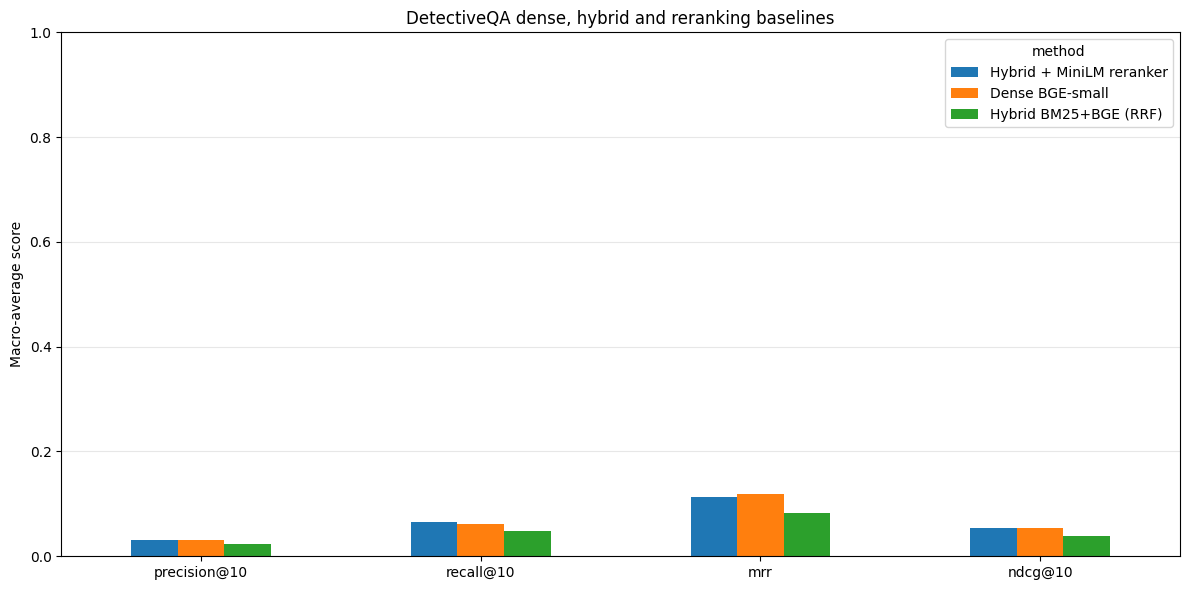

In [10]:
import matplotlib.pyplot as plt

metric_cols = ["precision@10","recall@10","mrr","ndcg@10"]
summary = (
    per_query.groupby("method",as_index=False)[metric_cols]
    .mean()
    .sort_values("recall@10",ascending=False)
    .reset_index(drop=True)
)
summary["queries"] = per_query["query_id"].nunique()

display(summary.style.format({c:"{:.4f}" for c in metric_cols}))

ax = summary.set_index("method")[metric_cols].T.plot(
    kind="bar", figsize=(12,6)
)
ax.set_title("DetectiveQA dense, hybrid and reranking baselines")
ax.set_ylabel("Macro-average score")
ax.set_ylim(0,1)
ax.grid(axis="y",alpha=.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Xem top-10 của một query

In [11]:
EXAMPLE_QUERY_ID = "" #@param {type:"string"}
EXAMPLE_PIPELINE = "hybrid_rerank" #@param ["dense","hybrid_rrf","hybrid_rerank"]

qid = EXAMPLE_QUERY_ID or eval_qids[0]
df = pd.DataFrame(runs[EXAMPLE_PIPELINE])
df = df[df["query_id"] == qid].sort_values("rank").head(10).copy()
df["text"] = df["doc_id"].map(lambda d: corpus[d]["text"][:400])

print("Query:", queries[qid])
print("Gold:", sorted(gold[qid]))
display(df)

Query: Alyona advised Polo not to tell anyone when she left, which implies that:
Gold: ['dqa-en-117-p101', 'dqa-en-117-p103', 'dqa-en-117-p107', 'dqa-en-117-p226', 'dqa-en-117-p229', 'dqa-en-117-p246', 'dqa-en-117-p441', 'dqa-en-117-p478', 'dqa-en-117-p92', 'dqa-en-117-p94', 'dqa-en-117-p98']


,query_id,doc_id,rank,cross_encoder_score,hybrid_rrf_score,reranked,relevant,text
1200,dqa-en-human_anno-117-q000,dqa-en-117-p883,1,4.967301,0.032522,True,0,"Polo said, ""Yes, because Mrs. Marshall asked m..."
1201,dqa-en-human_anno-117-q000,dqa-en-117-p2022,2,0.376869,0.028898,True,0,"""Alyona recently received a large sum of money..."
1202,dqa-en-human_anno-117-q000,dqa-en-117-p612,3,-0.331899,0.022723,True,0,"Poirot nodded. ""There's one more thing I must ..."
1203,dqa-en-human_anno-117-q000,dqa-en-117-p1526,4,-2.900980,0.027623,True,0,"""Ah, I've already given my opinion, it's a cri..."
1204,dqa-en-human_anno-117-q000,dqa-en-117-p923,5,-2.995666,0.021507,True,0,"Linda said, ""Yes."" She added, ""Alyona is very ..."
1205,dqa-en-human_anno-117-q000,dqa-en-117-p313,6,-3.527323,0.031025,True,0,"""Alyona is not good to Linda, really. I think ..."
1206,dqa-en-human_anno-117-q000,dqa-en-117-p919,7,-4.944320,0.024642,True,0,"""Around one o'clock, I - later - I heard - abo..."
1207,dqa-en-human_anno-117-q000,dqa-en-117-p314,8,-5.017097,0.017028,True,0,Kenneth Marshall lit a match to light his pipe...
1208,dqa-en-human_anno-117-q000,dqa-en-117-p2018,9,-5.813985,0.017308,True,0,"Polo pondered, ""When we were sitting here chat..."
1209,dqa-en-human_anno-117-q000,dqa-en-117-p878,10,-7.090683,0.016878,True,0,"""She said she didn't."""
